# Chapter 3: Implicit Differentiation Through a Fit — FWHM loss

## The Complete Pipeline

1. Draw samples from N(mu, sigma=1) where `mu` is trainable
2. Square the samples: `y = x^2`
3. Fit a pseudo-Voigt PDF to the y-values by maximum likelihood (L-BFGS) → optimal params `theta* = (log_gamma, center)`
4. **Compute the FWHM of the fitted distribution from `theta*`** and set `Loss = (FWHM_fit - target)^2`
5. Optimize `mu` via gradient descent

**What changed from the gamma-target version:** instead of matching the raw `gamma` parameter, we now match the **full-width at half-maximum (FWHM)** — a physical linewidth read off the *fitted distribution*. This adds one more link to the chain rule: `dLoss/dmu = 2(FWHM-target) · dFWHM/dlog_gamma · dlog_gamma/dmu`.

**The problem:** Step 3 (the fit) is an iterative optimization (L-BFGS) that blocks gradients.

**The solution:** Implicit differentiation — we differentiate *around* the fit using the optimality condition to get `dtheta*/dmu`, then push it through the differentiable FWHM formula.

## The Pseudo-Voigt PDF and its FWHM

The **pseudo-Voigt** is a weighted sum of a Gaussian and a Lorentzian:

$V(x) = \eta \cdot G(x) + (1-\eta) \cdot L(x)$

Fully differentiable in PyTorch. Only `gamma` (Lorentzian half-width, via `log_gamma` for positivity) and `center` are fitted; `sigma_g` and `eta` are fixed.

Its **FWHM** combines the Gaussian width $f_G = 2\sqrt{2\ln 2}\,\sigma_g$ and the Lorentzian width $f_L = 2\gamma$ through the Thompson–Cox–Hastings relation:

$f = \left(f_G^5 + 2.69269\,f_G^4 f_L + 2.42843\,f_G^3 f_L^2 + 4.47163\,f_G^2 f_L^3 + 0.07842\,f_G f_L^4 + f_L^5\right)^{1/5}$

This is a smooth, monotonic, differentiable function of the fitted `log_gamma` — exactly what we need to backprop the outer loss.

In [1]:
import torch
import math
import matplotlib.pyplot as plt

torch.manual_seed(42)
plt.rcParams.update({
    'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25,
    'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 11,
})

# --- Fixed shape params (only gamma & center are fitted) ---
SIGMA_G = torch.tensor([5.0])   # Gaussian width (fixed)
ETA     = torch.tensor([0.5])   # Gaussian/Lorentzian mixing weight (fixed)
n_samples = 100

def pseudo_voigt_pdf(x, log_gamma, sigma_g, center, eta):
    """Pseudo-Voigt PDF. gamma = exp(log_gamma) to keep it positive."""
    gamma = torch.exp(log_gamma)
    gauss = torch.exp(-0.5 * ((x - center) / sigma_g) ** 2) / (sigma_g * torch.sqrt(torch.tensor(2 * torch.pi)))
    lorentz = (gamma / torch.pi) / ((x - center) ** 2 + gamma ** 2)
    return eta * gauss + (1 - eta) * lorentz

# --- FWHM of the pseudo-Voigt from its shape params (Thompson-Cox-Hastings) ---
# f_G = Gaussian FWHM, f_L = Lorentzian FWHM -> one differentiable linewidth.
_GAUSS_FWHM_CONST = 2.0 * math.sqrt(2.0 * math.log(2.0))   # ~2.3548

def voigt_fwhm(log_gamma, sigma_g):
    """Differentiable pseudo-Voigt FWHM computed from the fitted shape params."""
    f_G = _GAUSS_FWHM_CONST * sigma_g
    f_L = 2.0 * torch.exp(log_gamma)
    f = (f_G**5 + 2.69269 * f_G**4 * f_L + 2.42843 * f_G**3 * f_L**2
         + 4.47163 * f_G**2 * f_L**3 + 0.07842 * f_G * f_L**4 + f_L**5) ** 0.2
    return f

print('Ready. FWHM at gamma=1 :', round(voigt_fwhm(torch.tensor([0.0]), SIGMA_G).item(), 3))

Ready. FWHM at gamma=1 : 12.852


## Step 1: Sample → Square → Fit → read the FWHM

We draw samples from N(mu, 1), square them, fit a pseudo-Voigt by maximum likelihood, then read the **FWHM straight off the fitted params**.

y values: mean = 26.56, std = 10.15


Fitted: gamma = 9.26, center = 24.19  ->  FWHM = 24.47


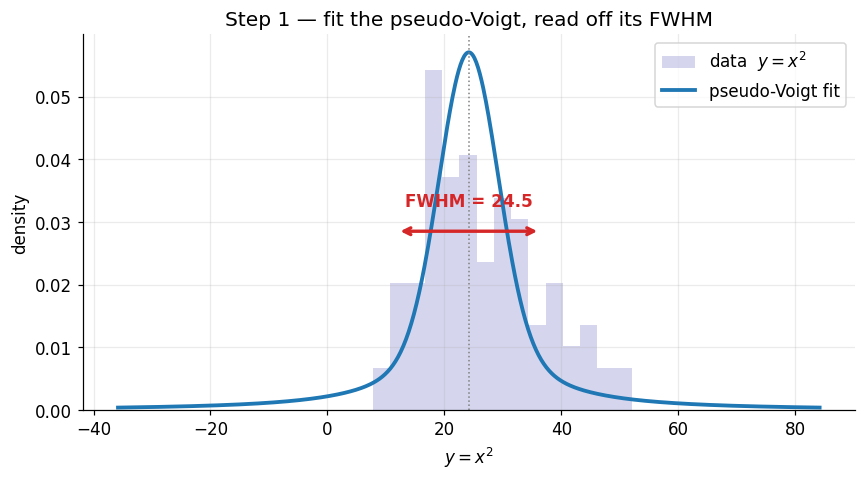

In [2]:
# Generate data: 100 samples from N(mu=5, 1), then square
mu_true = 5.0
torch.manual_seed(42)
x_samp = torch.randn(n_samples) + mu_true
y_data = x_samp ** 2
print(f'y values: mean = {y_data.mean().item():.2f}, std = {y_data.std().item():.2f}')

# Fit pseudo-Voigt: optimise (log_gamma, center) by maximum likelihood
log_gamma  = torch.tensor([2.0], requires_grad=True)
center_fit = torch.tensor([y_data.mean().item()], requires_grad=True)   # data-driven init
opt = torch.optim.LBFGS([log_gamma, center_fit], max_iter=200, lr=0.5)

def nll_loss():
    opt.zero_grad()
    pdf = pseudo_voigt_pdf(y_data.detach(), log_gamma, SIGMA_G, center_fit, ETA)
    loss = -torch.sum(torch.log(pdf + 1e-10))
    loss.backward()
    return loss

opt.step(nll_loss)
gamma_fit = torch.exp(log_gamma).item()
fwhm_fit  = voigt_fwhm(log_gamma.detach(), SIGMA_G).item()
print(f'Fitted: gamma = {gamma_fit:.2f}, center = {center_fit.item():.2f}  ->  FWHM = {fwhm_fit:.2f}')

# --- Visualise the fit and mark the FWHM ---
c = center_fit.item()
x_grid = torch.linspace(c - 60, c + 60, 800)
pdf_vals = pseudo_voigt_pdf(x_grid, log_gamma.detach(), SIGMA_G, center_fit.detach(), ETA)
peak = pdf_vals.max().item()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(y_data.numpy(), bins=15, density=True, alpha=0.35, color='#8888cc', label='data  $y=x^2$')
ax.plot(x_grid.numpy(), pdf_vals.detach().numpy(), color='#1f77b4', lw=2.5, label='pseudo-Voigt fit')
# FWHM span drawn at half the peak height, centred on the fitted centre
y_half = peak / 2
ax.annotate('', xy=(c - fwhm_fit/2, y_half), xytext=(c + fwhm_fit/2, y_half),
            arrowprops=dict(arrowstyle='<->', color='#d62728', lw=2.2))
ax.text(c, y_half * 1.14, f'FWHM = {fwhm_fit:.1f}', color='#d62728', ha='center', fontweight='bold')
ax.axvline(c, color='gray', ls=':', lw=1)
ax.set_xlabel('$y = x^2$'); ax.set_ylabel('density'); ax.legend()
ax.set_title('Step 1 — fit the pseudo-Voigt, read off its FWHM')
plt.tight_layout(); plt.show()

## What the loss sees: the mu → FWHM map

Before optimising, let's look at the landscape. For each `mu` we regenerate data, fit, and read the FWHM. The map is smooth and monotonic — so a target FWHM pins down a specific `mu`.

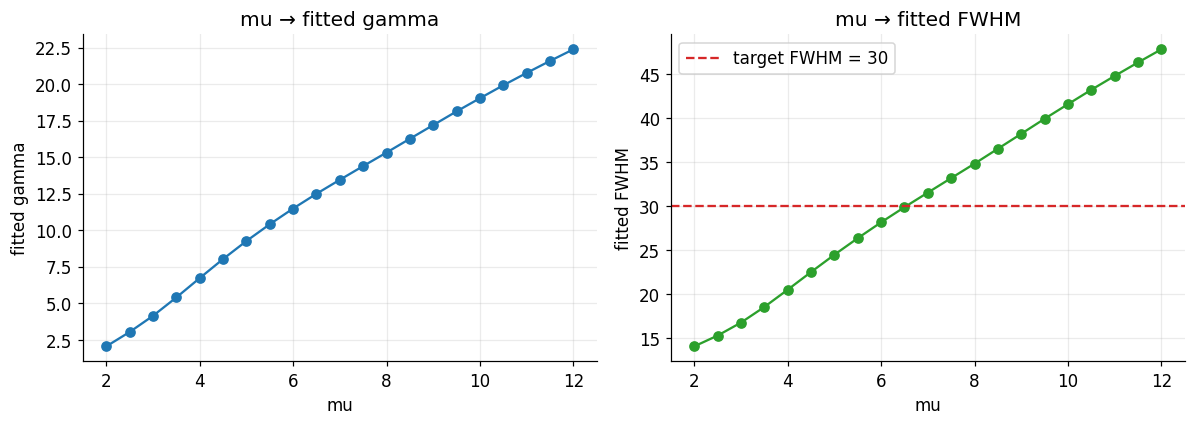

Smooth & monotonic — target FWHM = 30 sits around mu ~ 6.5


In [3]:
# Sweep mu -> see how the *fitted* gamma and FWHM depend on the trainable mean
TARGET_FWHM = 30.0
mu_scan = torch.linspace(2.0, 12.0, 21)
gam_scan, fwhm_scan = [], []
for m in mu_scan:
    torch.manual_seed(42)
    y = (torch.randn(n_samples) + m) ** 2
    lg = torch.tensor([2.0], requires_grad=True)
    cf = torch.tensor([y.mean().item()], requires_grad=True)
    o = torch.optim.LBFGS([lg, cf], max_iter=200, lr=0.5)
    def clo():
        o.zero_grad()
        pdf = pseudo_voigt_pdf(y.detach(), lg, SIGMA_G, cf, ETA)
        l = -torch.sum(torch.log(pdf + 1e-10)); l.backward(); return l
    o.step(clo)
    gam_scan.append(torch.exp(lg.detach()).item())
    fwhm_scan.append(voigt_fwhm(lg.detach(), SIGMA_G).item())

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(mu_scan.numpy(), gam_scan, 'o-', color='#1f77b4')
ax[0].set_xlabel('mu'); ax[0].set_ylabel('fitted gamma'); ax[0].set_title('mu → fitted gamma')
ax[1].plot(mu_scan.numpy(), fwhm_scan, 'o-', color='#2ca02c')
ax[1].axhline(TARGET_FWHM, color='#d62728', ls='--', label=f'target FWHM = {TARGET_FWHM:.0f}')
ax[1].set_xlabel('mu'); ax[1].set_ylabel('fitted FWHM'); ax[1].set_title('mu → fitted FWHM'); ax[1].legend()
plt.tight_layout(); plt.show()
print(f'Smooth & monotonic — target FWHM = {TARGET_FWHM:.0f} sits around mu ~ 6.5')

## Step 2: Implicit Differentiation — One Step

At the optimal fit, the inner-loss gradient is zero. Changing `mu` shifts the data and hence the optimum:

$\frac{d\theta^*}{d\mu} = -\mathbf{H}^{-1} \cdot \frac{\partial^2 L}{\partial \theta \, \partial \mu}$

Then we chain through the FWHM formula to get the gradient the outer loss actually needs:

$\frac{d\mathrm{FWHM}}{d\mu} = \frac{\partial \mathrm{FWHM}}{\partial \log\gamma} \cdot \frac{d\log\gamma^*}{d\mu}$

In [4]:
mu = torch.tensor([5.0], requires_grad=True)
torch.manual_seed(42)
y_data_grad = (torch.randn(n_samples) + mu) ** 2   # carries grad w.r.t. mu

# --- inner fit ---
lg = torch.tensor([2.0], requires_grad=True)
cf = torch.tensor([y_data_grad.mean().item()], requires_grad=True)
opt = torch.optim.LBFGS([lg, cf], max_iter=200, lr=0.5)
def closure():
    opt.zero_grad()
    pdf = pseudo_voigt_pdf(y_data_grad.detach(), lg, SIGMA_G, cf, ETA)
    loss = -torch.sum(torch.log(pdf + 1e-10)); loss.backward(); return loss
opt.step(closure)
print(f'Fit: gamma = {torch.exp(lg).item():.4f}, FWHM = {voigt_fwhm(lg.detach(), SIGMA_G).item():.4f}')

# --- implicit differentiation: dtheta*/dmu ---
lg_opt = lg.detach().clone().requires_grad_(True)
cf_opt = cf.detach().clone().requires_grad_(True)
pdf = pseudo_voigt_pdf(y_data_grad, lg_opt, SIGMA_G, cf_opt, ETA)
loss_inner = -torch.sum(torch.log(pdf + 1e-10))
grad_lg, grad_cf = torch.autograd.grad(loss_inner, [lg_opt, cf_opt], create_graph=True)
print(f'Gradient at optimum: dL/dlog_gamma = {grad_lg.item():.4f}, dL/dcenter = {grad_cf.item():.4f}')

# Hessian of the inner loss
H = torch.zeros(2, 2)
for i, g in enumerate([grad_lg, grad_cf]):
    for j, p in enumerate([lg_opt, cf_opt]):
        H[i, j] = torch.autograd.grad(g, p, retain_graph=True)[0].item()
print(f'Hessian:\n{H}')

# Mixed second derivatives w.r.t. mu
mixed = torch.tensor([[torch.autograd.grad(grad_lg, mu, retain_graph=True)[0].item()],
                      [torch.autograd.grad(grad_cf, mu, retain_graph=True)[0].item()]])
dtheta_dmu = -torch.linalg.solve(H, mixed)
dlog_gamma_dmu = dtheta_dmu[0, 0].item()

# --- chain rule through the FWHM formula ---
lg_f = lg.detach().clone().requires_grad_(True)
dfwhm_dlog_gamma = torch.autograd.grad(voigt_fwhm(lg_f, SIGMA_G), lg_f)[0].item()
dfwhm_dmu = dfwhm_dlog_gamma * dlog_gamma_dmu
print(f'dlog_gamma*/dmu   = {dlog_gamma_dmu:.4f}')
print(f'dFWHM/dlog_gamma  = {dfwhm_dlog_gamma:.4f}')
print(f'dFWHM/dmu         = {dfwhm_dmu:.4f}   <- implicit-diff gradient through the whole fit')

Fit: gamma = 9.2640, FWHM = 24.4742
Gradient at optimum: dL/dlog_gamma = -0.0048, dL/dcenter = 0.0004
Hessian:
tensor([[30.5306,  0.2010],
        [ 0.2010,  1.2511]])
dlog_gamma*/dmu   = 0.2569
dFWHM/dlog_gamma  = 14.9736
dFWHM/dmu         = 3.8474   <- implicit-diff gradient through the whole fit


## Step 3: Full Optimization Loop

Now we use the implicit gradient `dFWHM/dmu` to optimize `mu` so that the **fitted FWHM** reaches a target value. Loss = `(FWHM_fit - target)^2`.

step  0: mu=3.180  FWHM_fit=16.760  (target 30)


step  5: mu=4.080  FWHM_fit=20.098  (target 30)


step 10: mu=4.980  FWHM_fit=23.700  (target 30)
step 15: mu=5.880  FWHM_fit=27.081  (target 30)


step 20: mu=6.517  FWHM_fit=30.165  (target 30)


step 25: mu=6.535  FWHM_fit=30.012  (target 30)


step 30: mu=6.539  FWHM_fit=29.999  (target 30)


step 35: mu=6.539  FWHM_fit=30.003  (target 30)

Final: mu=6.537, FWHM_fit=29.997, target=30


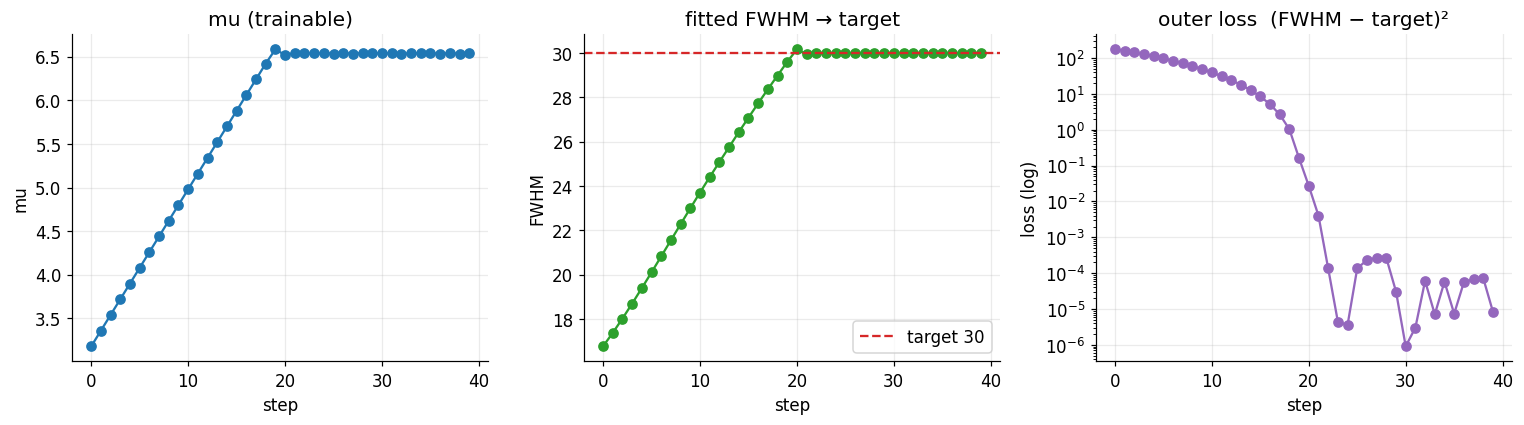

In [5]:
TARGET_FWHM = 30.0
mu = torch.tensor([3.0])
lr = 0.06
n_steps = 40

# history: (step, mu, fwhm_fit, gamma_fit, center_fit, log_gamma)
history = []

for step in range(n_steps):
    torch.manual_seed(42)
    y_data_step = (torch.randn(n_samples) + mu) ** 2

    # --- inner fit ---
    lg = torch.tensor([2.0], requires_grad=True)
    cf = torch.tensor([y_data_step.mean().item()], requires_grad=True)
    opt_inner = torch.optim.LBFGS([lg, cf], max_iter=200, lr=0.5)
    def closure():
        opt_inner.zero_grad()
        pdf = pseudo_voigt_pdf(y_data_step.detach(), lg, SIGMA_G, cf, ETA)
        loss = -torch.sum(torch.log(pdf + 1e-10)); loss.backward(); return loss
    opt_inner.step(closure)
    gamma_fitted = torch.exp(lg).detach().item()
    fwhm_fitted  = voigt_fwhm(lg.detach(), SIGMA_G).item()

    # --- implicit diff: dtheta*/dmu ---
    mu_grad = mu.clone().requires_grad_(True)
    torch.manual_seed(42)
    y_grad = (torch.randn(n_samples) + mu_grad) ** 2
    lg_opt = lg.detach().clone().requires_grad_(True)
    cf_opt = cf.detach().clone().requires_grad_(True)
    pdf = pseudo_voigt_pdf(y_grad, lg_opt, SIGMA_G, cf_opt, ETA)
    loss_inner = -torch.sum(torch.log(pdf + 1e-10))
    grad_lg, grad_cf = torch.autograd.grad(loss_inner, [lg_opt, cf_opt], create_graph=True)

    H = torch.zeros(2, 2)
    for i, g in enumerate([grad_lg, grad_cf]):
        for j, p in enumerate([lg_opt, cf_opt]):
            H[i, j] = torch.autograd.grad(g, p, retain_graph=True)[0].item()
    H += torch.eye(2) * 1e-3
    mixed = torch.tensor([[torch.autograd.grad(grad_lg, mu_grad, retain_graph=True)[0].item()],
                          [torch.autograd.grad(grad_cf, mu_grad, retain_graph=True)[0].item()]])
    dtheta_dmu = -torch.linalg.solve(H, mixed)

    # --- chain rule through FWHM ---
    lg_f = lg.detach().clone().requires_grad_(True)
    dfwhm_dlog_gamma = torch.autograd.grad(voigt_fwhm(lg_f, SIGMA_G), lg_f)[0].item()
    dfwhm_dmu = dfwhm_dlog_gamma * dtheta_dmu[0, 0].item()

    # --- outer loss = (FWHM - target)^2, gradient descent on mu ---
    grad_mu = 2 * (fwhm_fitted - TARGET_FWHM) * dfwhm_dmu
    grad_mu = max(min(grad_mu, 3.0), -3.0)   # clip for stability
    mu = (mu - lr * grad_mu).clamp(0.0, 20.0)

    history.append((step, mu.item(), fwhm_fitted, gamma_fitted, cf.item(), lg.detach().item()))
    if step % 5 == 0:
        print(f'step {step:2d}: mu={mu.item():.3f}  FWHM_fit={fwhm_fitted:.3f}  (target {TARGET_FWHM:.0f})')

print(f'\nFinal: mu={mu.item():.3f}, FWHM_fit={history[-1][2]:.3f}, target={TARGET_FWHM:.0f}')

# --- development dashboard ---
steps  = [h[0] for h in history]
mus    = [h[1] for h in history]
fwhms  = [h[2] for h in history]
losses = [(h[2] - TARGET_FWHM) ** 2 for h in history]

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].plot(steps, mus, 'o-', color='#1f77b4')
ax[0].set_title('mu (trainable)'); ax[0].set_xlabel('step'); ax[0].set_ylabel('mu')
ax[1].plot(steps, fwhms, 'o-', color='#2ca02c')
ax[1].axhline(TARGET_FWHM, color='#d62728', ls='--', label=f'target {TARGET_FWHM:.0f}')
ax[1].set_title('fitted FWHM → target'); ax[1].set_xlabel('step'); ax[1].set_ylabel('FWHM'); ax[1].legend()
ax[2].semilogy(steps, losses, 'o-', color='#9467bd')
ax[2].set_title('outer loss  (FWHM − target)²'); ax[2].set_xlabel('step'); ax[2].set_ylabel('loss (log)')
plt.tight_layout(); plt.show()

## The development of the fitted distribution

The most telling picture for a talk: watch the **fitted pseudo-Voigt itself** evolve across the optimisation. Each curve is re-centred at 0 so we see only the width changing as the FWHM is driven to its target.

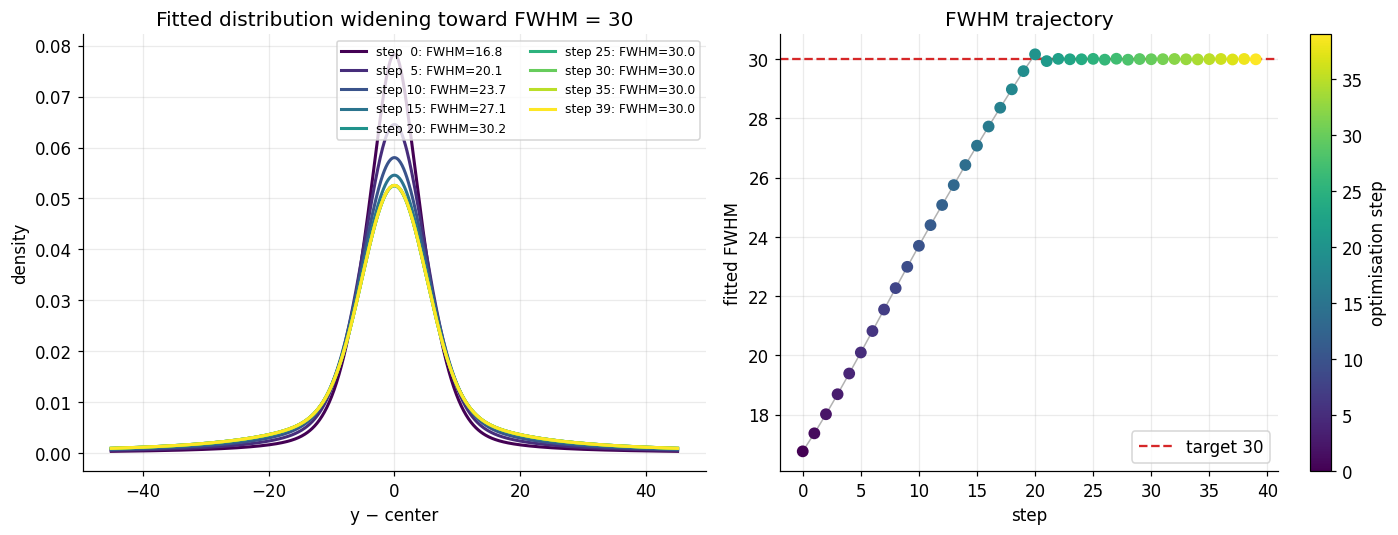

In [6]:
# Evolution of the fitted pseudo-Voigt (all re-centred at 0), coloured by step
last_step = history[-1][0]
idxs = list(range(0, len(history), max(1, len(history) // 7)))
if idxs[-1] != len(history) - 1:
    idxs.append(len(history) - 1)

cmap = plt.cm.viridis
xr = torch.linspace(-45, 45, 700)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# left: the widening distributions
for i in idxs:
    step, muv, fwhmv, gamv, cenv, lgv = history[i]
    pdf = pseudo_voigt_pdf(xr, torch.tensor([lgv]), SIGMA_G, torch.tensor([0.0]), ETA)
    ax[0].plot(xr.numpy(), pdf.detach().numpy(), color=cmap(step / last_step),
               lw=2, label=f'step {step:2d}: FWHM={fwhmv:.1f}')
ax[0].set_xlabel('y − center'); ax[0].set_ylabel('density')
ax[0].set_title(f'Fitted distribution widening toward FWHM = {TARGET_FWHM:.0f}')
ax[0].legend(fontsize=8, ncol=2)

# right: FWHM trajectory coloured the same way (ties the two panels together)
sc = ax[1].scatter(steps, fwhms, c=steps, cmap=cmap, s=45, zorder=3)
ax[1].plot(steps, fwhms, color='gray', lw=1, alpha=0.6, zorder=1)
ax[1].axhline(TARGET_FWHM, color='#d62728', ls='--', label=f'target {TARGET_FWHM:.0f}')
ax[1].set_xlabel('step'); ax[1].set_ylabel('fitted FWHM')
ax[1].set_title('FWHM trajectory'); ax[1].legend()

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, last_step)); sm.set_array([])
plt.colorbar(sm, ax=ax[1], label='optimisation step')
plt.tight_layout(); plt.show()

## Summary

1. **Pipeline:** N(mu, 1) → square → pseudo-Voigt fit → `theta* = (log_gamma, center)` → **FWHM(theta\*)** → loss → optimize `mu`
2. **New loss:** instead of matching the raw `gamma`, we match the **FWHM** — a physical linewidth read off the *fitted distribution* via the differentiable Thompson–Cox–Hastings formula
3. **Implicit differentiation** gives `dtheta*/dmu` without backpropagating through L-BFGS; the chain rule then adds `dFWHM/dlog_gamma`
4. The optimization converges: `mu` starts at 3.0 and finds the value that makes `FWHM_fit` hit the target
5. **Practical tricks:** `log_gamma` for positivity, data-driven `center` init (keeps the inner fit from collapsing), gradient clipping and a small Hessian ridge for stability